<a href="https://colab.research.google.com/github/borgesjose/Fundamentals-of-Quantum-Computing/blob/main/Superdense_Comunication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
!pip install qiskit qiskit-aer pylatexenc;

In [56]:
# Imports principais
from qiskit import QuantumCircuit,QuantumRegister,ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import DensityMatrix, partial_trace
# Simulador
from qiskit_aer import AerSimulator

# (Opcional) Melhor visualização inline
%matplotlib inline

import numpy as np

# Bloco de Preparação

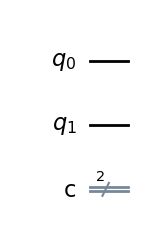

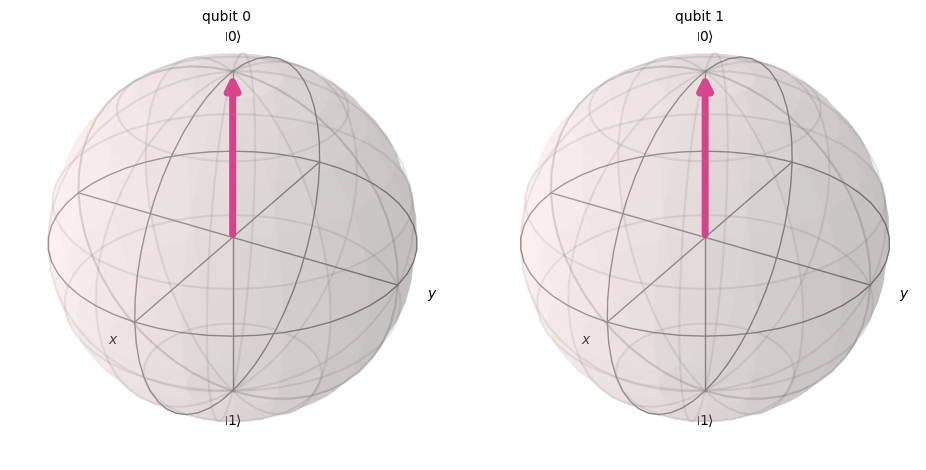

In [57]:
# 1. Cria um registro quântico com 2 qubits
qReg = QuantumRegister(2, 'q')

c = ClassicalRegister(2,'c')

# 2. Inicializa o circuito quântico 'qa' com o registro criado
qa = QuantumCircuit(qReg,c)

# 3. Desenha o circuito inicial (qubits em |0>)
display(qa.draw('mpl'))

# 4. Exibe a Esfera de Bloch mostrando ambos os qubits no topo (estado |0>)
display(plot_bloch_multivector(Statevector.from_instruction(qa)))

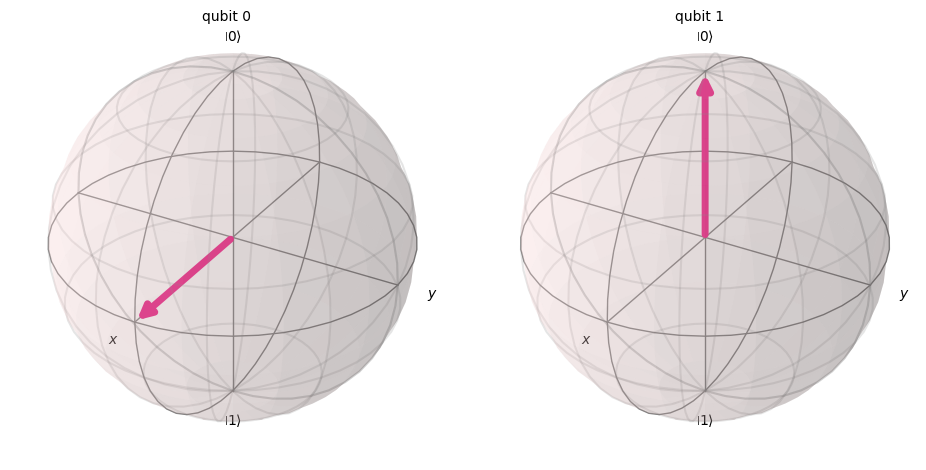

In [58]:
# 1. Aplica a porta Hadamard no qubit 0 para criar superposição
qa.h(qReg[0])

# 2. Visualiza a mudança na Esfera de Bloch (vetor rotaciona para o eixo X)
display(plot_bloch_multivector(Statevector.from_instruction(qa)))

In [59]:
qa.cx(qReg[0], qReg[1]);

=== Diagrama do Circuito de Codificação ===


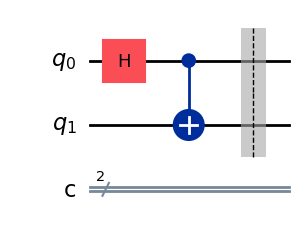

In [60]:
# 1. Imprime um cabeçalho para identificação
print("=== Diagrama do Circuito de Codificação ===")
qa.barrier()
# 2. Desenha o diagrama final completo usando o backend Matplotlib
display(qa.draw("mpl"))

Fim da preparação dos qubits. Fim do emaranhamento.

# Bloco de encoder

In [61]:
message = '10'

In [62]:
# 00: Do nothing (I)
if message == '00':
  pass
# 01: Apply X gate
elif message == '01':
  qa.z(qReg[0])
# 10: Apply Z gate
elif message == '10':
  qa.x(qReg[0])
# 11: Apply Z then X gate
elif message == '11':
  qa.z(qReg[0])
  qa.x(qReg[0])

In [63]:
qa.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

Fim do encoder da infromação no qbit.

# Bloco de decoder

In [65]:
qa.cx(qReg[0], qReg[1]);
qa.h(qReg[0])

=== Diagrama do Circuito ===


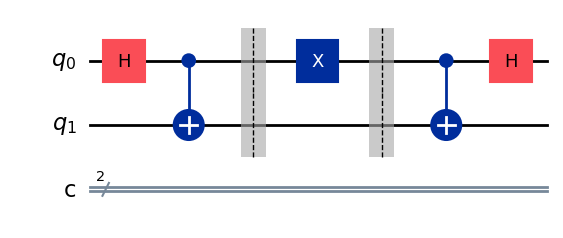

In [66]:
# 1. Imprime um cabeçalho para identificação
print("=== Diagrama do Circuito ===")

# 2. Desenha o diagrama final completo usando o backend Matplotlib
display(qa.draw("mpl"))

In [67]:
qa.measure(qReg,c) # Qubits measured


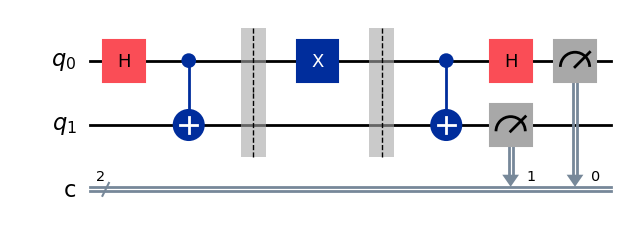

In [68]:
display(qa.draw("mpl"))

Para saber o valor de um registrador clássico após a medição, você precisa executar o circuito quântico em um simulador e, em seguida, recuperar os resultados da medição.

In [69]:
# 1. Crie uma instância do AerSimulator
simulator = AerSimulator()

# 2. Execute o circuito no simulador
job = simulator.run(qa, shots=1024) # shots define o número de vezes que o circuito é executado
result = job.result()

# 3. Obtenha as contagens dos resultados
counts = result.get_counts(qa)

# 4. Exiba as contagens
print("Contagens de medição:", counts)

Contagens de medição: {'10': 1024}


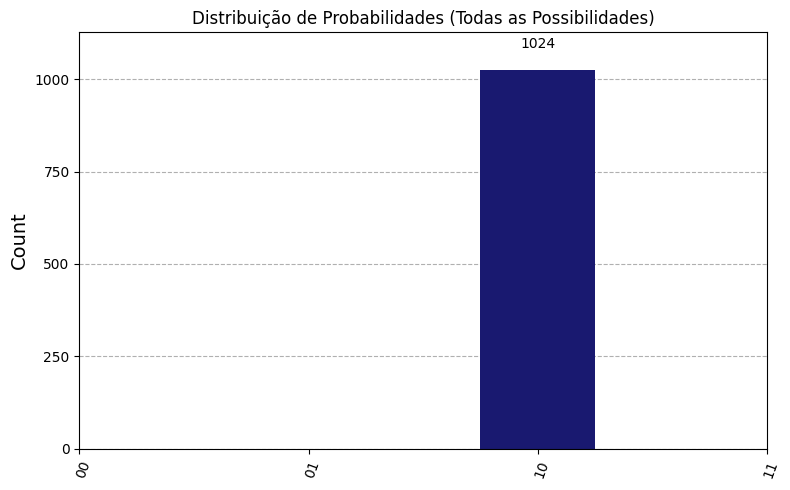

In [77]:
from qiskit.visualization import plot_histogram

# 1. Defina um template com todas as 4 possibilidades de medição (00, 01, 10, 11)
#    Note que as chaves aqui são strings simples, que é o formato esperado por `plot_histogram` e `counts`.
all_outcomes_template = {'00': 0, '01': 0, '10': 0, '11': 0}

# 2. Crie um novo dicionário e copie as contagens do simulador para ele
#    Isso preencherá as contagens existentes e manterá 0 para as não observadas.
full_counts = all_outcomes_template.copy()
full_counts.update(counts)

# 3. Defina um título para o gráfico
titulo_completo = "Distribuição de Probabilidades (Todas as Possibilidades)"

# 4. Plote o histograma usando o dicionário `full_counts`
display(plot_histogram(full_counts, title=titulo_completo, figsize=(8, 5), color='midnightblue'))